# Interpolation

examples

In [ ]:
import numpy as np
from functools import reduce, lru_cache

from scipy import linalg as la
import scipy.optimize as opt
from scipy import special, interpolate, integrate
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
np.set_printoptions(suppress=True, precision=6)  # 抑制科学计数法，小数位6位

def sign(x):
    s = np.sign(x)
    return s if s else 1

In [52]:
# 7.1
nodes = [-2, 0, 1]
b = [-27, -1, 0]


def monomial_coef(nodes, b):
    A = np.vander(nodes, increasing=True)
    return la.solve(A, b)


monomial_coef(nodes, b)

array([-1.,  5., -4.])

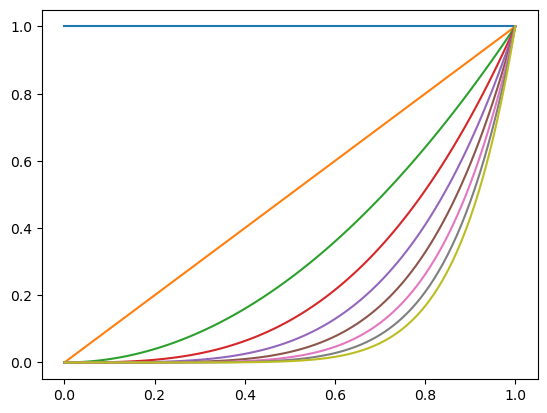

In [53]:
# fig 7.1
x = np.arange(101) / 100
for i in range(9):
    plt.plot(x, (lambda x: x ** i)(x))

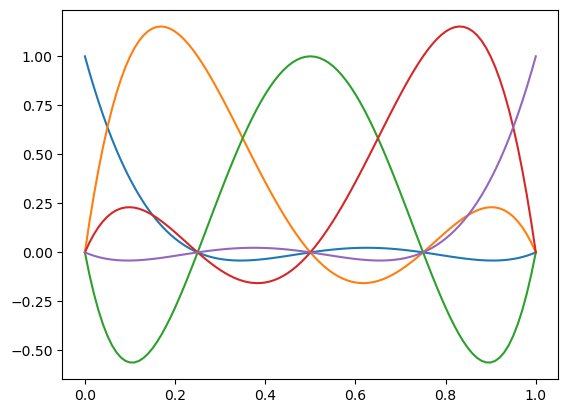

In [54]:
# fig 7.2
nodes = np.linspace(0, 1, 5)


def lagrange_bases(nodes):
    nodes = np.array(nodes, dtype=float)
    n = len(nodes)
    lx = [reduce(Polynomial.__mul__, [Polynomial([-a, 1])for a in nodes[np.arange(n) != i]]) for i in range(n)]
    wx = [1 / (nodes[i] - nodes[np.arange(n) != i]).prod() for i in range(n)]
    return [l * w for l, w in zip(lx, wx)]


x = np.linspace(0, 1, 101)
for p in lagrange_bases(nodes):
    plt.plot(x, p(x))

In [55]:
# 7.2
nodes = [-2, 0, 1]
ps = lagrange_bases(nodes)
ys = [-27, -1, 0]

sum([y * p  for y, p in zip(ys, ps)])

Polynomial([-1.,  5., -4.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

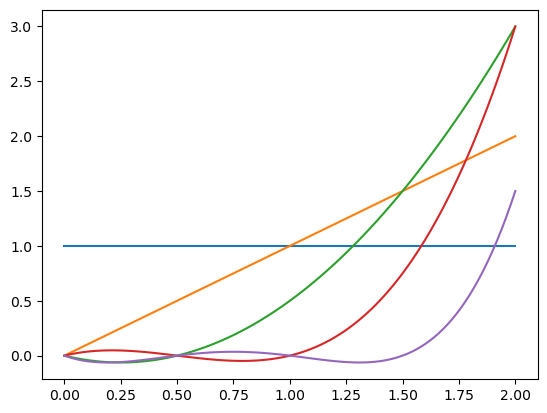

In [56]:
def newton_bases(nodes):
    nodes = np.array(nodes, dtype=float)
    n = len(nodes)
    return [Polynomial([1])] + [reduce(Polynomial.__mul__, [Polynomial([-a, 1]) for a in nodes[:i+1]]) for i in range(n-1)]


nodes = np.linspace(0, 2, 5)

x = np.linspace(0, 2, 101)
for p in newton_bases(nodes):
    plt.plot(x, p(x))

In [57]:
# 7.3
# (a) linear system
nodes = [-2, 0, 1]
b = [-27, -1, 0]

def optimize_nodes_b(nodes, b):
    # sync change nodes and b
    nodes_b = sorted(zip(nodes, b), key=lambda x: abs(x[0] - nodes.mean()))
    nodes = np.array([t for t, _ in nodes_b], dtype=float)
    b = np.array([y for _, y in nodes_b], dtype=float)
    return nodes, b


def newton_coef_axb(nodes, b):
    nodes = np.array(nodes, dtype=float)
    ps = newton_bases(nodes)
    A = np.array([p(nodes) for p in ps]).T
    # print(np.linalg.cond(A))
    return la.solve(A, b)
    

newton_coef_axb(nodes, b)

array([-27.,  13.,  -4.])

In [58]:
# (b) incremental
nodes = [-2, 0, 1]
b = [-27, -1, 0]

def newton_incr(q, p, x, y):
    return (y - q(x)) / p(x)


def newton_coef_incr(nodes, b):
    ps = newton_bases(nodes)
    qs = [Polynomial([b[0]])]
    xs = [b[0]]
    for i in range(1, len(nodes)):
        xs.append(newton_incr(qs[-1], ps[i], nodes[i], b[i]))
        qs.append(qs[-1] + xs[-1] * ps[i])
    return np.array(xs)


newton_coef_incr(nodes, b)

array([-27.,  13.,  -4.])

In [59]:
# (c) recursive
def newton_coef_recur(nodes, b):

    @lru_cache
    def divided_difference(i, j):
        if i == j:
            return b[i]
        else:
            return (divided_difference(i+1, j) - divided_difference(i, j-1)) / (nodes[j] - nodes[i])
        
    return np.array([divided_difference(0, i) for i in range(len(nodes))])


newton_coef_recur(nodes, b)

array([-27.,  13.,  -4.])

In [60]:
from numpy.polynomial import Legendre
p = Legendre.basis(4)
p.convert(kind=Polynomial)

Polynomial([ 0.375,  0.   , -3.75 ,  0.   ,  4.375], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

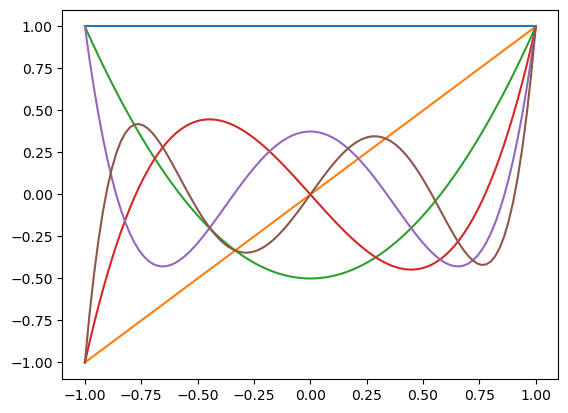

In [61]:
# fig 7.4
x = np.linspace(-1, 1, 101)
for i in range(6):
    plt.plot(x, special.legendre(i)(x))

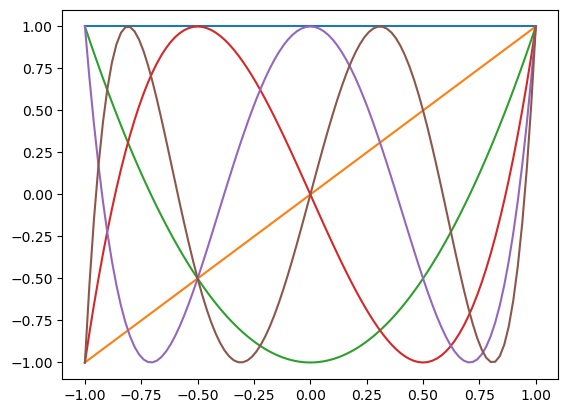

In [62]:
x = np.linspace(-1, 1, 101)

for i in range(6):
    plt.plot(x, special.chebyt(i)(x))

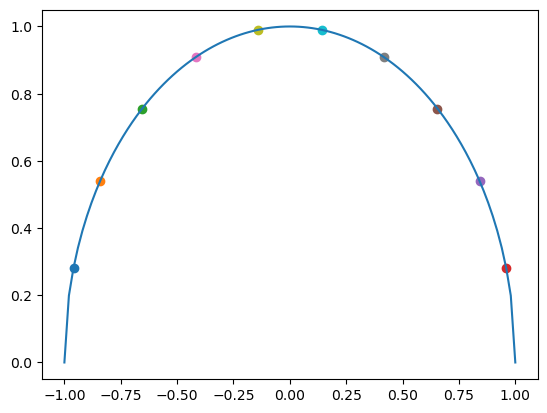

In [63]:
# fig 7.6
def f(x):
    return np.sqrt(1 - x ** 2)

x = np.linspace(-1, 1, 101)
plt.plot(x, f(x))
for x in special.chebyu(10).roots:
    plt.scatter(x, f(x))

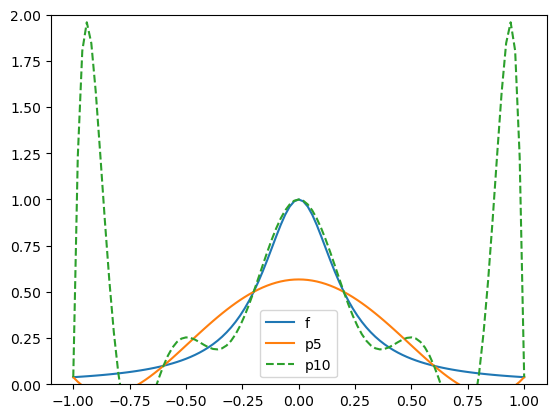

In [64]:
# fig 7.7
def f(x):
    return 1 / (1 + 25 * x ** 2)


x6 = np.linspace(-1, 1, 6)
p5 = sum([w * p for w, p in zip(newton_coef_incr(x6, f(x6)), newton_bases(x6))])

x11 = np.linspace(-1, 1, 11)
p10 = sum([w * p for w, p in zip(f(x11), lagrange_bases(x11))])

x = np.linspace(-1, 1, 101)
plt.plot(x, f(x), label='f')
plt.plot(x, p5(x), label='p5')
plt.plot(x, p10(x), linestyle='--', label='p10')
plt.ylim(0, 2)
plt.legend()

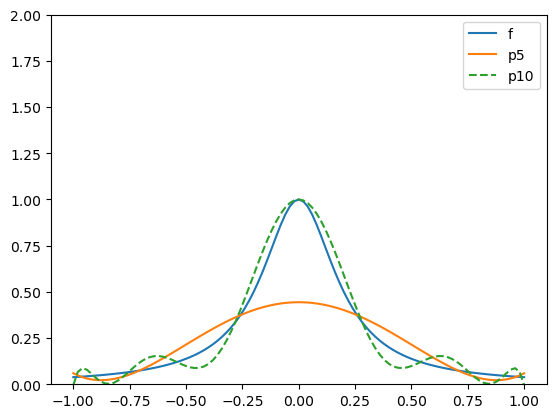

In [65]:
# 7.8
x6 = special.chebyt(6).roots
p5 = sum([w * p for w, p in zip(newton_coef_incr(x6, f(x6)), newton_bases(x6))])

x11 = special.chebyt(11).roots
p10 = sum([w * p for w, p in zip(f(x11), lagrange_bases(x11))])

x = np.linspace(-1, 1, 101)
plt.plot(x, f(x), label='f')
plt.plot(x, p5(x), label='p5')
plt.plot(x, p10(x), linestyle='--', label='p10')
plt.ylim(0, 2)
plt.legend()

exercises

In [66]:
# 7.1
nodes = [-1, 0, 1]
b = [1, 0, 1]
# (a)
print(monomial_coef(nodes, b))
# (b)
print(b)
# (c)
print(newton_coef_axb(nodes, b)[0])
print(newton_coef_recur(nodes, b))
print(newton_coef_incr(nodes, b))

[0. 0. 1.]
[1, 0, 1]
1.0
[ 1. -1.  1.]
[ 1. -1.  1.]


In [ ]:
# 7.3
def monomial_horner(coef, x):
    s = np.zeros_like(x) if isinstance(x, np.ndarray) else 0
    for a in coef[::-1][:-1]:
        s = (s + a) * x
    s += coef[0]
    return s


def newton_horner(coef, x, nodes):
    coef, nodes = coef[::-1], nodes[::-1]
    s = np.zeros_like(x) if isinstance(x, np.ndarray) else 0
    for a, t in zip(coef, nodes[1:]):
        s = (s + a) * (x - t)
    s += coef[-1]
    return s

In [68]:
# 7.5
# (a)
nodes = [1, 2, 3, 4]
b = [11, 29, 65, 125]


def monomial_bases(nodes):
    return [Polynomial([0] * n + [1]) for n in range(len(nodes))]


sum([w * p for w, p in zip(monomial_coef(nodes, b), monomial_bases(nodes))])

Polynomial([5., 2., 3., 1.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

In [69]:
# (b)
sum([w * p for w, p in zip(b, lagrange_bases(nodes))])

Polynomial([5., 2., 3., 1.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

In [70]:
# (c)
sum([w * p for w, p in zip(newton_coef_incr(nodes, b), newton_bases(nodes))])

Polynomial([5., 2., 3., 1.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

In [71]:
# 7.6
# loose upper bound
(np.pi / 2 / 4) ** 5 / 4 / 5 # 0.0004669

nodes = np.linspace(0, np.pi / 2, 5)
b = np.sin(nodes)

coef = monomial_coef(nodes, b)
p = Polynomial(coef)

for x in np.random.random(10) * np.pi / 2:
    print(np.abs(np.sin(x) - p(x)).round(4))


0.0001
0.0001
0.0
0.0001
0.0001
0.0001
0.0
0.0001
0.0002
0.0001


In [72]:
# check horner routine
print(np.allclose([np.abs(monomial_horner(coef, x) - p(x)) for x in np.random.random(10) * np.pi / 2], 0))
    
coef = newton_coef_incr(nodes, b)
print(np.allclose([np.abs(newton_horner(coef, x, nodes) - p(x)) for x in np.random.random(10) * np.pi / 2], 0))

True
True


In [73]:
# 7.12
# (a)
from scipy import integrate

A = np.zeros((6, 6), dtype=float)
for i in range(6):
    for j in range(6):
        A[i, j] = integrate.quad(Legendre.basis(i) * Legendre.basis(j), -1, 1)[0]
print(A.round(3))

# (b)
from numpy.polynomial import Legendre
all((k + 1) * Legendre.basis(k+1) - (2 * k + 1) * Polynomial([0, 1]).convert(kind=Legendre) * Legendre.basis(k) + k * Legendre.basis(k-1) == Legendre([0]) for k in range(1, 100))

[[2.    0.    0.    0.    0.    0.   ]
 [0.    0.667 0.    0.    0.    0.   ]
 [0.    0.    0.4   0.    0.    0.   ]
 [0.    0.    0.    0.286 0.    0.   ]
 [0.    0.    0.    0.    0.222 0.   ]
 [0.    0.    0.    0.    0.    0.182]]


True

In [74]:
# (c)
for p in monomial_bases(range(6)):
    print(p.convert(kind=Legendre))

1.0
0.0 + 1.0 P_1(x)
0.333333 + 0.0 P_1(x) + 0.666667 P_2(x)
0.0 + 0.6 P_1(x) + 0.0 P_2(x) + 0.4 P_3(x)
0.2 + 0.0 P_1(x) + 0.571429 P_2(x) + 0.0 P_3(x) + 0.228571 P_4(x)
0.0 + 0.428571 P_1(x) + 0.0 P_2(x) + 0.444444 P_3(x) + 0.0 P_4(x) +
0.126984 P_5(x)


computer problems

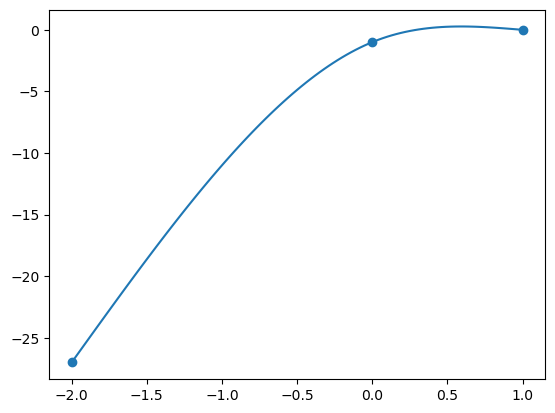

In [75]:
# 7.3
nodes = [-2, 0, 1]
b = [-27, -1, 0]
cs = interpolate.CubicSpline(nodes, b, bc_type='natural')
x = np.linspace(-2, 1, 101)
plt.plot(x, cs(x))
plt.scatter(nodes, b)

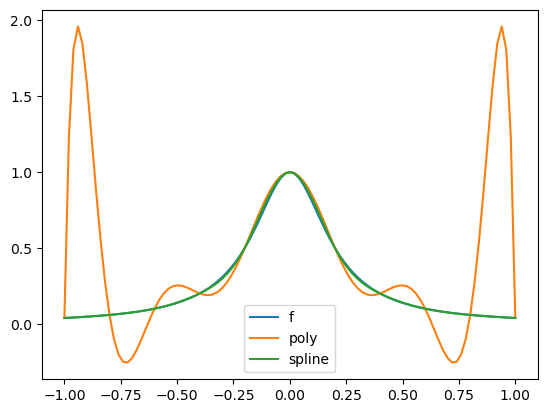

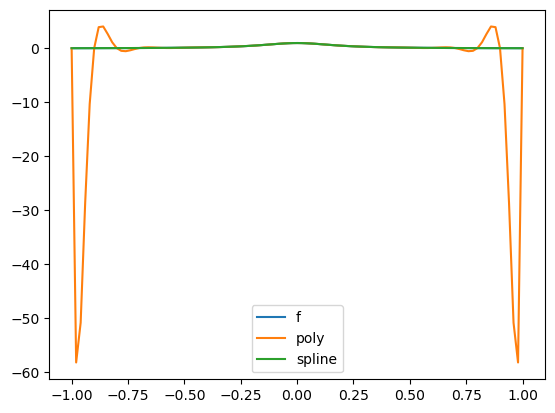

In [76]:
# 7.4
def f(x):
    return 1 / (1 + 25 * x ** 2)

for n in 11, 21:
    x = np.linspace(-1, 1, n)
    q = sum(w * p for w, p in zip(newton_coef_incr(x, f(x)), newton_bases(x)))
    cs = interpolate.CubicSpline(x, f(x), bc_type='natural')
    plt.figure()
    x = np.linspace(-1, 1, 101)
    plt.plot(x, f(x), label='f')
    plt.plot(x, q(x), label='poly')
    plt.plot(x, cs(x), label='spline')
    plt.legend()



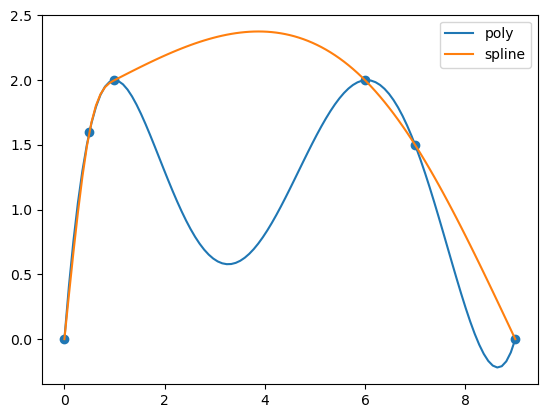

In [77]:
# 7.5
nodes = [0, .5, 1, 6, 7, 9]
b = [0, 1.6, 2, 2, 1.5, 0]

q = sum(w * p for w, p in zip(newton_coef_recur(nodes, b), newton_bases(nodes)))
cs = interpolate.CubicSpline(nodes, b, bc_type='natural')
plt.figure()
x = np.linspace(0, 9, 101)
plt.scatter(nodes, b)
plt.plot(x, q(x), label='poly')
plt.plot(x, cs(x), label='spline')
plt.legend()

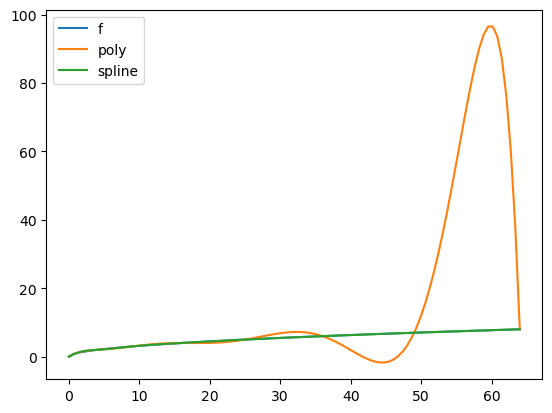

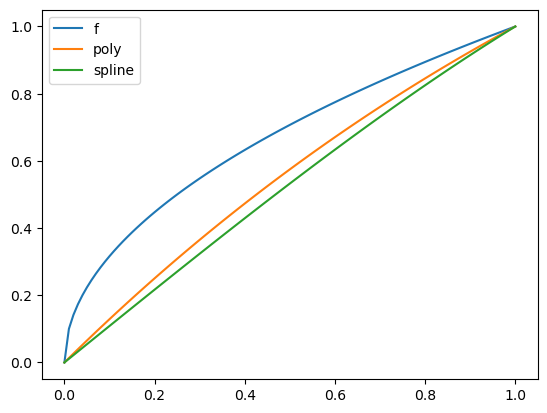

In [78]:
# 7.6
nodes = [n ** 2 for n in range(9)]
b = range(9)

q = sum(w * p for w, p in zip(newton_coef_recur(nodes, b), newton_bases(nodes)))
cs = interpolate.CubicSpline(nodes, b, bc_type='natural')
for xend in 64, 1:
    plt.figure()
    x = np.linspace(0, xend, 101)
    plt.plot(x, np.sqrt(x), label='f')
    plt.plot(x, q(x), label='poly')
    plt.plot(x, cs(x), label='spline')
    plt.legend()

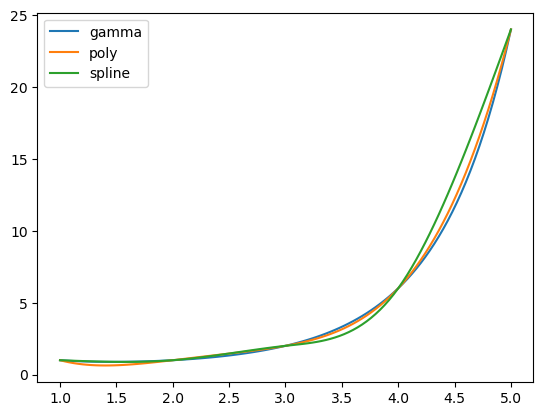

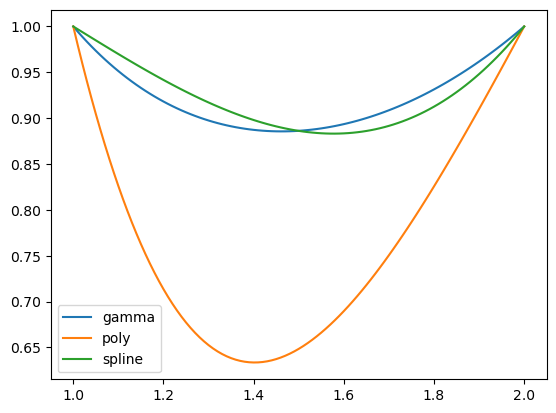

In [79]:
# 7.7
import math
nodes = range(1, 6)
b = [math.factorial(n - 1) for n in nodes]

q = sum(w * p for w, p in zip(b, lagrange_bases(nodes)))
cs = interpolate.CubicSpline(nodes, b, bc_type='natural')

for xend in 5, 2:
    x = np.linspace(1, xend, 101)
    plt.figure()
    plt.plot(x, special.gamma(x), label='gamma')
    plt.plot(x, q(x), label='poly')
    plt.plot(x, cs(x), label='spline')
    plt.legend()

In [80]:
# 7.8
nodes = np.array(range(1900, 1981, 10), dtype=float)
b = np.array([
    76_212_168,
    92_228_496,
    106_021_537,
    123_202_624,
    132_164_569,
    151_325_798,
    179_323_175,
    203_302_031,
    226_542_199,
])

# (a)
A1 = np.vander(nodes, increasing=True)
print(np.linalg.cond(A1))
A2 = np.vander(nodes - 1900, increasing=True)
print(np.linalg.cond(A2))
A3 = np.vander(nodes - 1940, increasing=True)
print(np.linalg.cond(A3))
A4 = np.vander((nodes - 1940) / 40, increasing=True)
print(np.linalg.cond(A4))

3.7101593789760927e+37
6313979296720109.0
9315536039407.74
1605.4437004786032


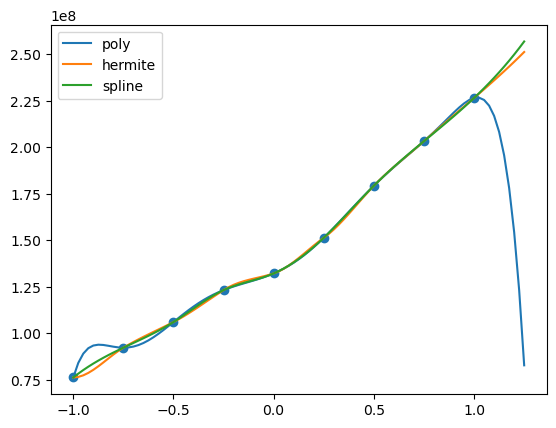

In [81]:
# (b) (c) (d)
def year_to_node(x):
    return (x - 1940) / 40


new_nodes = year_to_node(nodes)

q = sum(w * p for w, p in zip(monomial_coef(new_nodes, b), monomial_bases(new_nodes)))

gradient = np.diff(b) / np.diff(new_nodes)
gradient = np.concatenate([[0], gradient])
chs = interpolate.CubicHermiteSpline(new_nodes, b, gradient)
cs = interpolate.CubicSpline(new_nodes, b)


x = np.arange(1900, 1991, 1)
plt.plot(year_to_node(x), monomial_horner(q.coef, year_to_node(x)), label='poly')
plt.plot(year_to_node(x), chs(year_to_node(x)), label='hermite')
plt.plot(year_to_node(x), cs(year_to_node(x)), label='spline')
plt.scatter(new_nodes, b)
plt.legend()

In [82]:
# (e) 248_709_873
print(chs(year_to_node(1990)))
print(cs(year_to_node(1990)))

251259743.0
256915297.07564107


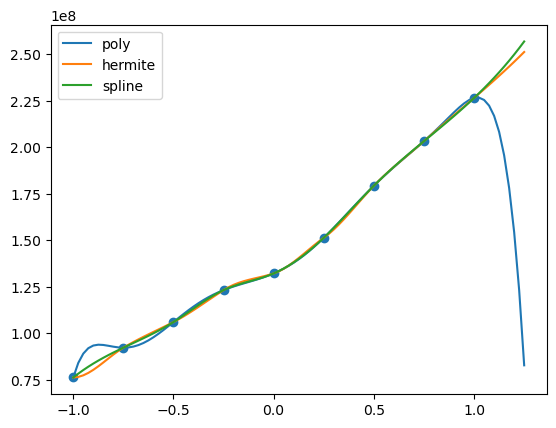

In [83]:
# (f)
q = sum(w * p for w, p in zip(b, lagrange_bases(new_nodes)))

x = np.arange(1900, 1991, 1)
plt.plot(year_to_node(x), q(year_to_node(x)), label='poly')
plt.plot(year_to_node(x), chs(year_to_node(x)), label='hermite')
plt.plot(year_to_node(x), cs(year_to_node(x)), label='spline')
plt.scatter(new_nodes, b)
plt.legend()

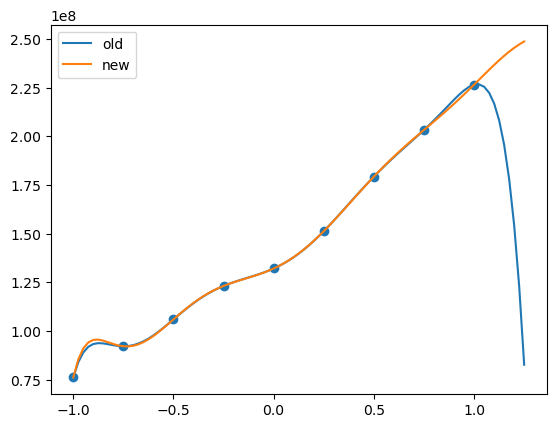

In [84]:
# (g)
q_old = sum(w * p for w, p in zip(newton_coef_recur(new_nodes, b), newton_bases(new_nodes)))

augmented_nodes = np.concatenate([new_nodes, [year_to_node(1990)]])
p = newton_bases(augmented_nodes)[-1]
w = newton_incr(q_old, p, year_to_node(1990), 248_709_873)
q_new = q_old + w * p

x = np.arange(1900, 1991, 1)
plt.plot(year_to_node(x), q_old(year_to_node(x)), label='old')
plt.plot(year_to_node(x), q_new(year_to_node(x)), label='new')
plt.scatter(new_nodes, b)
plt.legend()

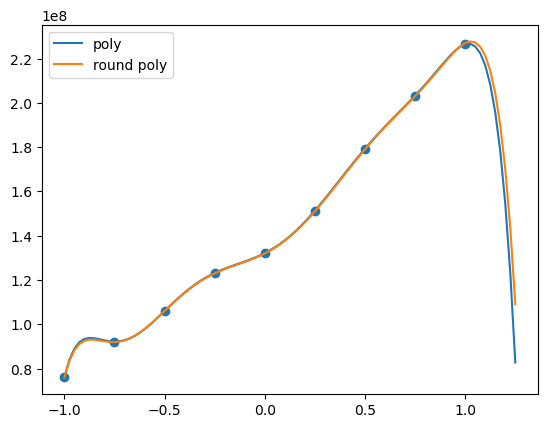

In [88]:
# (h)
q_round = sum(w * p for w, p in zip(newton_coef_axb(new_nodes, b.round(-6)), newton_bases(new_nodes)))
x = np.arange(1900, 1991, 1)
plt.plot(year_to_node(x), monomial_horner(q.coef, year_to_node(x)), label='poly')
plt.plot(year_to_node(x), monomial_horner(q_round.coef, year_to_node(x)), label='round poly')

plt.scatter(new_nodes, b)
plt.legend()